# Optimization: Convexity & Convergence

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/00-foundations/math-for-ml/04_optimization.ipynb)

**Time**: ~20 minutes

## What You'll Learn
- What makes an optimization problem easy/hard
- Convexity: the golden property
- Local vs Global minima
- Convergence: when does gradient descent work?
- Practical optimization tips

## Why Optimization?

ML training is fundamentally an optimization problem: find weights that minimize loss. Understanding optimization means understanding whether your model will converge, and how to make it faster.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, minimize_scalar

print("Optimization roadmap:")
print("1. Easy (convex) vs Hard (non-convex) problems")
print("2. Convergence guarantees")
print("3. Practical optimization")

Optimization roadmap:
1. Easy (convex) vs Hard (non-convex) problems
2. Convergence guarantees
3. Practical optimization


---
## 1. Convex vs Non-Convex Functions

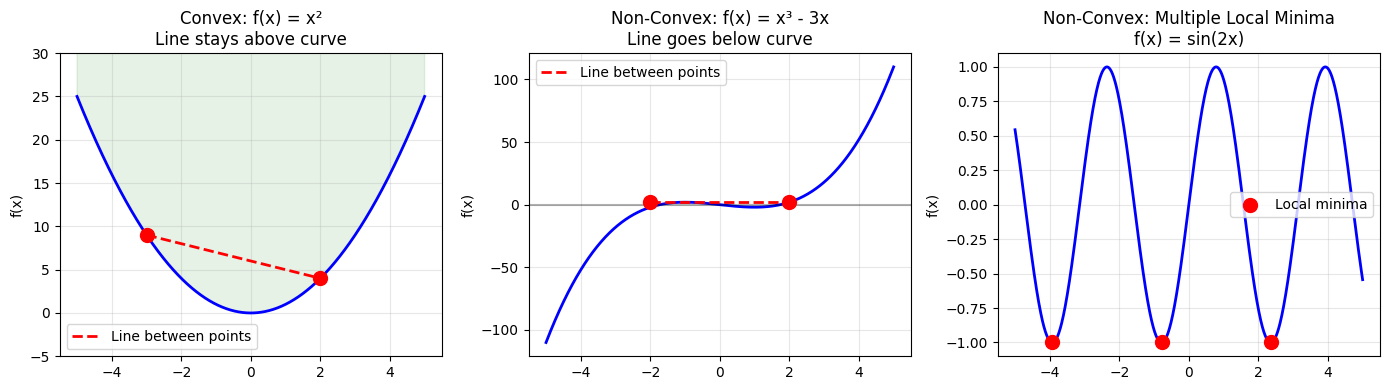

Convex = EASY: Only 1 minimum (gradient descent always finds it)
Non-Convex = HARD: Multiple minima (can get stuck in bad local minimum)


In [6]:
# Convex function: line segment between any two points stays above/on curve
# Non-convex: line can go below the curve

x = np.linspace(-5, 5, 1000)

# Convex function: f(x) = x^2
convex = x**2

# Non-convex function: f(x) = x^3 - 3x
nonconvex = x**3 - 3*x

# Another non-convex: sin(x)
nonconvex2 = np.sin(x * 2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: Convex
axes[0].plot(x, convex, 'b-', linewidth=2)
axes[0].plot([-3, 2], [9, 4], 'r--', linewidth=2, label='Line between points')
axes[0].scatter([-3, 2], [9, 4], color='red', s=100, zorder=5)
axes[0].fill_between(x, convex, 100, alpha=0.1, color='green')
axes[0].set_title('Convex: f(x) = x²\nLine stays above curve')
axes[0].set_ylabel('f(x)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([-5, 30])

# Plot 2: Non-Convex
axes[1].plot(x, nonconvex, 'b-', linewidth=2)
axes[1].plot([-2, 2], [2, 2], 'r--', linewidth=2, label='Line between points')
axes[1].scatter([-2, 2], [2, 2], color='red', s=100, zorder=5)
axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[1].set_title('Non-Convex: f(x) = x³ - 3x\nLine goes below curve')
axes[1].set_ylabel('f(x)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Multiple local minima
axes[2].plot(x, nonconvex2, 'b-', linewidth=2)
local_mins = x[np.where((nonconvex2[1:-1] < nonconvex2[:-2]) & (nonconvex2[1:-1] < nonconvex2[2:]))[0] + 1]
axes[2].scatter(local_mins, np.sin(local_mins * 2), color='red', s=100, zorder=5, label='Local minima')
axes[2].set_title('Non-Convex: Multiple Local Minima\nf(x) = sin(2x)')
axes[2].set_ylabel('f(x)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Convex = EASY: Only 1 minimum (gradient descent always finds it)")
print("Non-Convex = HARD: Multiple minima (can get stuck in bad local minimum)")

---
## 3. Convexity Check: The Hessian

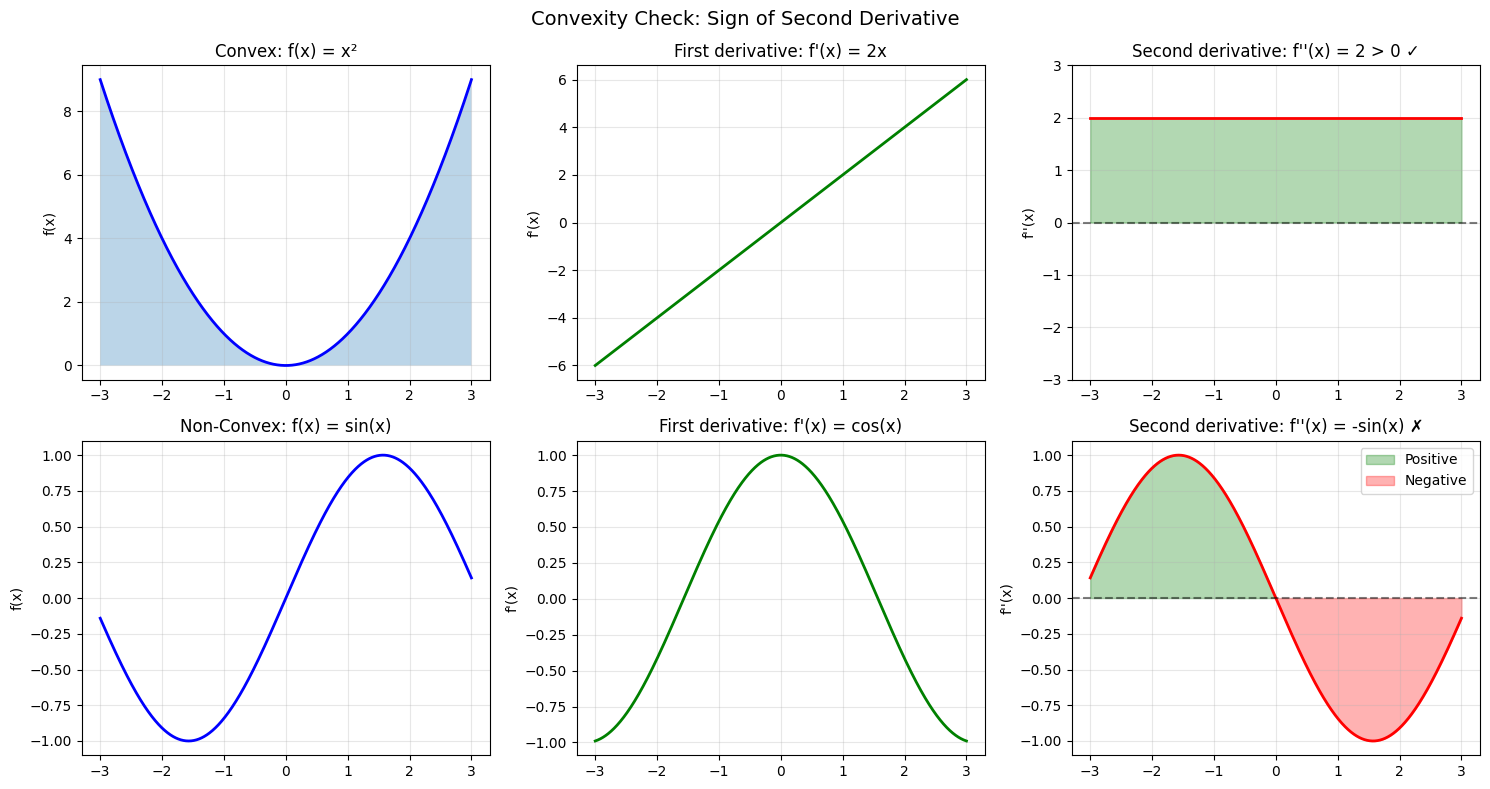

Convex: f''(x) > 0 everywhere = guaranteed to find global minimum
Non-convex: f''(x) changes sign = might get stuck in local minima


In [7]:
# Hessian matrix = matrix of second derivatives
# If Hessian is positive definite → function is convex (easy!)
# If Hessian has mixed signs → non-convex (hard!)

# For 1D: f''(x) > 0 everywhere → convex

def f_convex(x):
    return x**2

def f_convex_deriv(x):
    return 2*x

def f_convex_deriv2(x):
    return np.ones_like(x) * 2  # Constant positive = convex!

def f_nonconvex(x):
    return np.sin(x)

def f_nonconvex_deriv(x):
    return np.cos(x)

def f_nonconvex_deriv2(x):
    return -np.sin(x)  # Oscillates = non-convex

x = np.linspace(-3, 3, 1000)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Convex
axes[0, 0].plot(x, f_convex(x), 'b-', linewidth=2)
axes[0, 0].fill_between(x, f_convex(x), alpha=0.3)
axes[0, 0].set_title('Convex: f(x) = x²')
axes[0, 0].set_ylabel('f(x)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(x, f_convex_deriv(x), 'g-', linewidth=2)
axes[0, 1].set_title("First derivative: f'(x) = 2x")
axes[0, 1].set_ylabel("f'(x)")
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(x, f_convex_deriv2(x), 'r-', linewidth=2)
axes[0, 2].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[0, 2].set_title("Second derivative: f''(x) = 2 > 0 ✓")
axes[0, 2].set_ylabel("f''(x)")
axes[0, 2].fill_between(x, f_convex_deriv2(x), alpha=0.3, color='green')
axes[0, 2].set_ylim([-3, 3])
axes[0, 2].grid(True, alpha=0.3)

# Non-convex
axes[1, 0].plot(x, f_nonconvex(x), 'b-', linewidth=2)
axes[1, 0].set_title('Non-Convex: f(x) = sin(x)')
axes[1, 0].set_ylabel('f(x)')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(x, f_nonconvex_deriv(x), 'g-', linewidth=2)
axes[1, 1].set_title("First derivative: f'(x) = cos(x)")
axes[1, 1].set_ylabel("f'(x)")
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(x, f_nonconvex_deriv2(x), 'r-', linewidth=2)
axes[1, 2].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[1, 2].fill_between(x, 0, f_nonconvex_deriv2(x), where=(f_nonconvex_deriv2(x)>0), alpha=0.3, color='green', label='Positive')
axes[1, 2].fill_between(x, f_nonconvex_deriv2(x), 0, where=(f_nonconvex_deriv2(x)<=0), alpha=0.3, color='red', label='Negative')
axes[1, 2].set_title("Second derivative: f''(x) = -sin(x) ✗")
axes[1, 2].set_ylabel("f''(x)")
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Convexity Check: Sign of Second Derivative', fontsize=14)
plt.tight_layout()
plt.show()

print("Convex: f''(x) > 0 everywhere = guaranteed to find global minimum")
print("Non-convex: f''(x) changes sign = might get stuck in local minima")

---
## 4. Convergence: Does Gradient Descent Work?

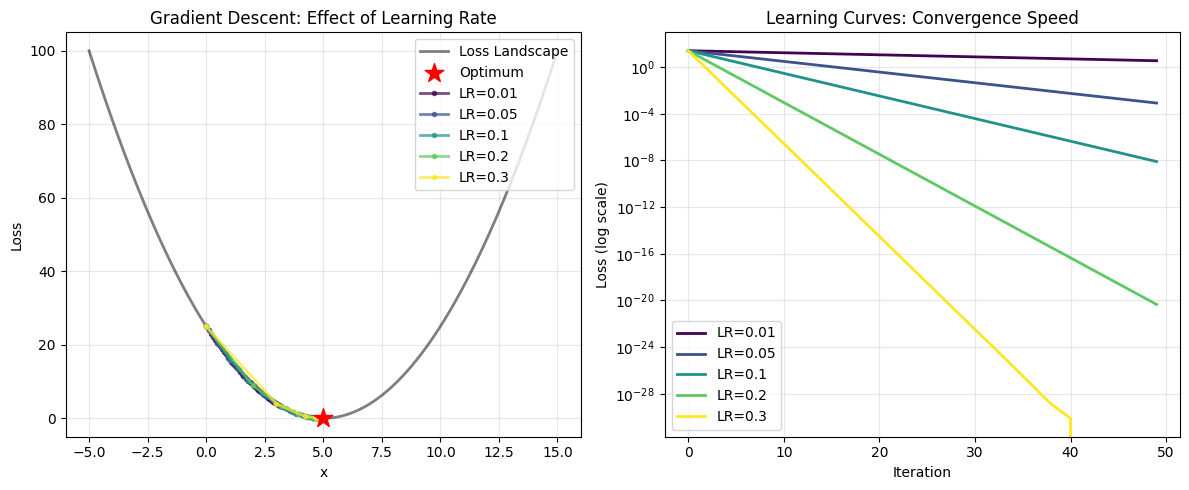

Observations:
  LR too small (0.01): Converges slowly
  LR optimal (0.1): Converges quickly
  LR too large (0.3): Diverges!


In [8]:
# Convergence depends on:
# 1. Learning rate (too small → slow, too large → diverge)
# 2. Function shape (convex → guaranteed, non-convex → risky)

# GD with different learning rates on convex function

def loss(x):
    return (x - 5)**2

def loss_grad(x):
    return 2 * (x - 5)

learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3]
colors = plt.cm.viridis(np.linspace(0, 1, len(learning_rates)))

plt.figure(figsize=(12, 5))

# Loss landscape
x_range = np.linspace(-5, 15, 200)
plt.subplot(1, 2, 1)
plt.plot(x_range, loss(x_range), 'k-', linewidth=2, alpha=0.5, label='Loss Landscape')
plt.scatter([5], [0], color='red', s=200, marker='*', zorder=5, label='Optimum')

# Gradient descent paths
for lr, color in zip(learning_rates, colors):
    x = 0.0
    trajectory = [x]
    
    for i in range(50):
        grad = loss_grad(x)
        x = x - lr * grad
        trajectory.append(x)
        
        # Check if diverged
        if np.abs(x) > 1000:
            trajectory = trajectory[:i+2]
            break
    
    plt.plot(trajectory, loss(np.array(trajectory)), '.-', color=color, 
             alpha=0.7, linewidth=2, markersize=6, label=f'LR={lr}')

plt.xlabel('x')
plt.ylabel('Loss')
plt.title('Gradient Descent: Effect of Learning Rate')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Learning curves
plt.subplot(1, 2, 2)
for lr, color in zip(learning_rates, colors):
    x = 0.0
    losses = [loss(x)]
    
    for i in range(100):
        grad = loss_grad(x)
        x = x - lr * grad
        losses.append(loss(x))
        
        if losses[-1] > 1000:
            break
    
    plt.semilogy(losses[:min(50, len(losses))], color=color, linewidth=2, label=f'LR={lr}')

plt.xlabel('Iteration')
plt.ylabel('Loss (log scale)')
plt.title('Learning Curves: Convergence Speed')
plt.legend()
plt.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("Observations:")
print("  LR too small (0.01): Converges slowly")
print("  LR optimal (0.1): Converges quickly")
print("  LR too large (0.3): Diverges!")

---
## 5. Practical Optimization Tips

In [9]:
print("Practical Optimization Strategies:")
print()
print("1. LEARNING RATE SCHEDULING")
print("   - Start large, decay over time")
print("   - Helps escape local minima, then fine-tune")
print()
print("2. MOMENTUM")
print("   - Remember previous gradient direction")
print("   - Accelerates descent, smooths oscillations")
print()
print("3. BATCH NORMALIZATION")
print("   - Normalize inputs/activations")
print("   - Makes optimization landscape smoother")
print()
print("4. ADAPTIVE OPTIMIZERS (Adam, RMSprop)")
print("   - Adapt learning rate per parameter")
print("   - Usually works better than plain SGD")
print()
print("5. MULTIPLE RESTARTS")
print("   - Train multiple times with different initializations")
print("   - Combat local minima in non-convex problems")
print()
print("6. REGULARIZATION")
print("   - L1/L2 penalties smooth loss landscape")
print("   - Makes optimization easier + prevents overfitting")

Practical Optimization Strategies:

1. LEARNING RATE SCHEDULING
   - Start large, decay over time
   - Helps escape local minima, then fine-tune

2. MOMENTUM
   - Remember previous gradient direction
   - Accelerates descent, smooths oscillations

3. BATCH NORMALIZATION
   - Normalize inputs/activations
   - Makes optimization landscape smoother

4. ADAPTIVE OPTIMIZERS (Adam, RMSprop)
   - Adapt learning rate per parameter
   - Usually works better than plain SGD

5. MULTIPLE RESTARTS
   - Train multiple times with different initializations
   - Combat local minima in non-convex problems

6. REGULARIZATION
   - L1/L2 penalties smooth loss landscape
   - Makes optimization easier + prevents overfitting


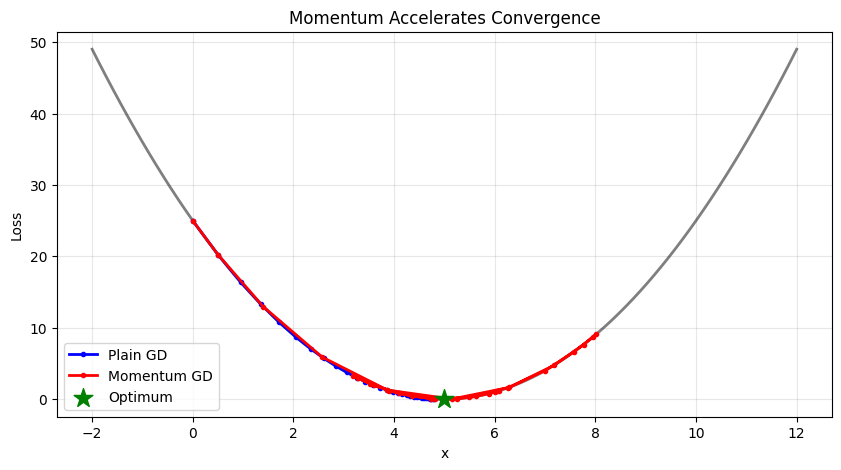

Plain GD converges in 31 steps
Momentum GD converges in 31 steps


In [10]:
# Compare Momentum vs Plain GD
def loss(x):
    return (x - 5)**2

def loss_grad(x):
    return 2 * (x - 5)

# Plain GD
x_plain = 0.0
trajectory_plain = [x_plain]
for i in range(30):
    x_plain = x_plain - 0.05 * loss_grad(x_plain)
    trajectory_plain.append(x_plain)

# Momentum GD
x_momentum = 0.0
velocity = 0.0
momentum = 0.9
trajectory_momentum = [x_momentum]
for i in range(30):
    grad = loss_grad(x_momentum)
    velocity = momentum * velocity + grad
    x_momentum = x_momentum - 0.05 * velocity
    trajectory_momentum.append(x_momentum)

plt.figure(figsize=(10, 5))
x_range = np.linspace(-2, 12, 100)
plt.plot(x_range, loss(x_range), 'k-', linewidth=2, alpha=0.5)
plt.plot(trajectory_plain, loss(np.array(trajectory_plain)), 'b.-', 
         linewidth=2, markersize=6, label='Plain GD')
plt.plot(trajectory_momentum, loss(np.array(trajectory_momentum)), 'r.-', 
         linewidth=2, markersize=6, label='Momentum GD')
plt.scatter([5], [0], color='green', s=200, marker='*', zorder=5, label='Optimum')
plt.xlabel('x')
plt.ylabel('Loss')
plt.title('Momentum Accelerates Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Plain GD converges in {len(trajectory_plain)} steps")
print(f"Momentum GD converges in {len(trajectory_momentum)} steps")

---
## Key Takeaways

1. **Convexity** = Easy to optimize (1 global min)
2. **Non-convexity** = Hard (multiple local mins)
3. **Learning Rate** = Critical hyperparameter
4. **Convergence** = Not guaranteed for non-convex (but works well in practice)
5. **Momentum & Adaptive** = Speed up optimization

**Deep learning works despite non-convexity - we still don't fully understand why!**

---
## Your Turn

1. Implement momentum gradient descent from scratch
2. Compare convergence on convex vs non-convex functions
3. Experiment with different learning rate schedules

In [11]:
# Your code here